# Split Factor with Tail Example: Convergence Analysis

This notebook compares convergence behavior between:

**Scenario 1: Splitting + Damping**
- 3 variable nodes: X1, X2, X3
- Split factors F12' and F12'' (symmetric split) with cost table [[4,10],[16,8]]
- Tail factor F23 (unary constraint) that always sends 10 to X2

**Scenario 2: Damping Only (No Splitting)**
- Factor F12 with full cost table [[8,20],[32,16]]
- Same F23 tail factor

We analyze when the message passes the threshold k=8 to converge to state (b, b).
We use **RDampingEngine** in both cases to dampen the R-messages (Factor -> Variable), specifically affecting the messages from F23.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

from propflow import FactorAgent, VariableAgent
from propflow.core.components import CostTable
from propflow.policies import split_specific_factors
from propflow.utils.fg_utils import FGBuilder
from propflow.bp.engine_base import BPEngine
from propflow.engines import DampingEngine, RDampingEngine
from propflow.snapshots import SnapshotVisualizer

## Convergence Theory

With damping factor $\lambda$, messages evolve as:
$$m^{(t)} = \lambda \cdot m^{(t-1)} + (1-\lambda) \cdot m_{\text{new}}$$

For a message converging to limit $L=10$, starting from **$m^{(0)} = 0$**:
$$m^{(t)} = 10 \cdot (1 - \lambda^t)$$

To find when message crosses threshold $k$:
$$t_{\min} = \left\lceil \frac{\ln\left(1 - \frac{k}{10}\right)}{\ln(\lambda)} \right\rceil$$

With $\lambda=0.5$:
$$t_{\min} = \left\lceil \log_{0.5}\left(1 - \frac{k}{10}\right) \right\rceil = \left\lceil \log_2\left(\frac{10}{10-k}\right) \right\rceil$$

In [2]:
def compute_t_min(m0: float, k: float, lam: float = 0.5) -> int:
    """Compute minimum iterations to cross threshold k starting from m0.
    
    Formula: t_min = ceil( log_2( (10 - m0) / (10 - k) ) )
    """
    if m0 >= k:
        return 0
    
    numerator = math.log((10 - m0) / (10 - k))
    denominator = math.log(1 / lam)
    return math.ceil(numerator / denominator)


def damped_message(m0: float, t: int, lam: float = 0.5, limit: float = 10.0) -> float:
    """Compute message value at iteration t with damping."""
    return limit + (lam ** t) * (m0 - limit)


# test the formulas for m0 = 0
m0 = 0.0
k = 8.0
lam = 0.5
limit = 10.0

t_min = compute_t_min(m0, k, lam)
msg_val = damped_message(m0, t_min, lam, limit)

print("=== Convergence Formula Verification ===")
print(f"Parameters: m0={m0}, k={k}, lambda={lam}, limit={limit}")
print(f"Predicted t_min: {t_min}")
print(f"Message at t={t_min}: {msg_val:.4f}")

=== Convergence Formula Verification ===
Parameters: m0=0.0, k=8.0, lambda=0.5, limit=10.0
Predicted t_min: 3
Message at t=3: 8.7500


---
## Scenario 1: Splitting + Damping

- Split factors F12', F12'' each with cost table [[4,10],[16,8]]
- F23 sends constant 10 to X2
- Threshold k=8 for converging to (b,b)

Scenario 1: Splitting + Damping
Split factors each have cost table:
[[ 4 10]
 [16  8]]


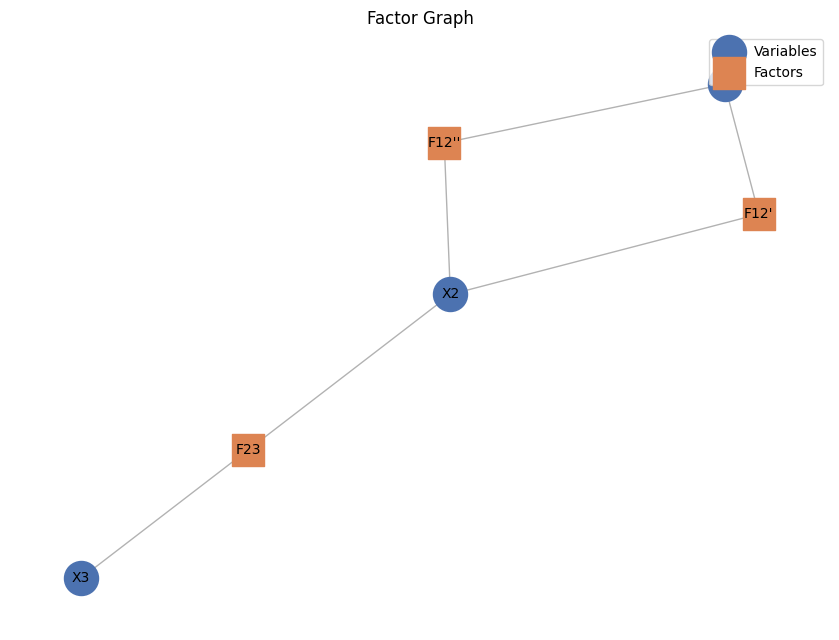

In [3]:
# scenario 1: splitting + damping
# each split factor has half the cost: [[4,10],[16,8]]

C12_split: CostTable = np.array([[4, 10],
                                  [16, 8]])

# unary constraint F23: designed to send constant 10 to X2
C23_unary: CostTable = np.array([[0, 10],
                                  [10, 0]])

# create variable nodes
X1_s1 = VariableAgent("X1", domain=2)
X2_s1 = VariableAgent("X2", domain=2)
X3_s1 = VariableAgent("X3", domain=2)

# create factor for X1-X2 (will be split)
F12_s1 = FactorAgent.create_from_cost_table("F12", cost_table=C12_split * 2)  # full cost before split

# create unary factor for X2-X3 
F23_s1 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

# build factor graph
fg_split = FGBuilder.build_from_edges(
    variables=[X1_s1, X2_s1, X3_s1],
    factors=[F12_s1, F23_s1],
    edges={F12_s1: [X1_s1, X2_s1], F23_s1: [X2_s1, X3_s1]},
)

# apply symmetric splitting to F12
split_specific_factors(fg_split, [F12_s1])

print("Scenario 1: Splitting + Damping")
print("Split factors each have cost table:")
print(C12_split)
fg_split.visualize(pretty=True)

Scenario 1: Ran 15 iterations with damping_factor=0.5


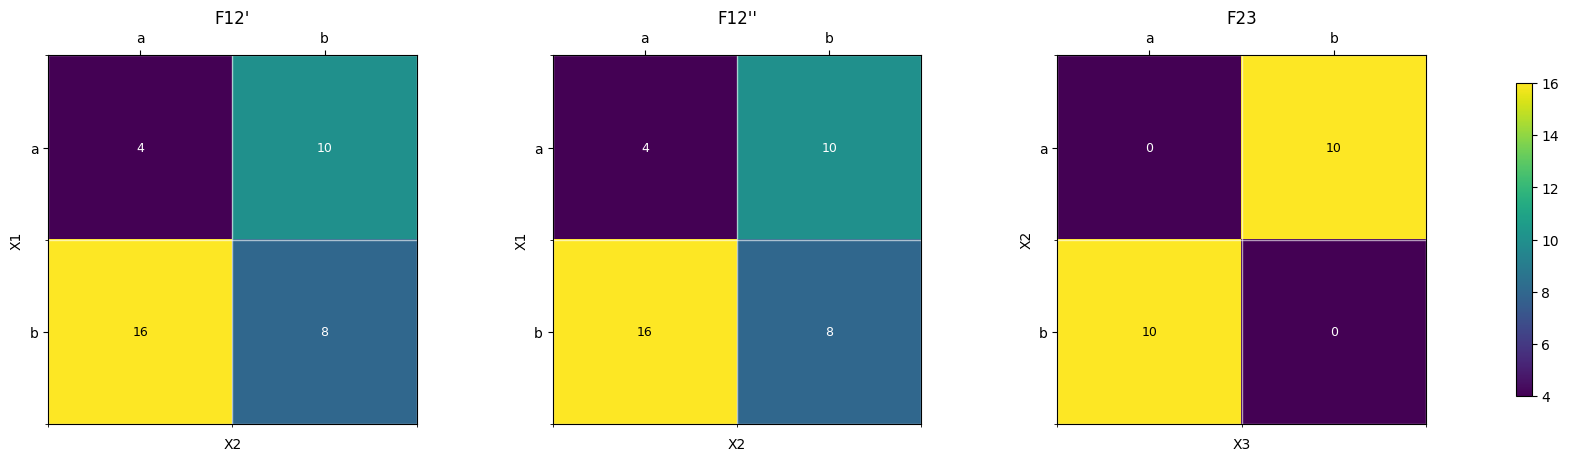

In [4]:
# run BP with R-damping on the split graph
damping_factor = 0.5
# Using RDampingEngine to damp messages from factors (specifically F23)
engine_split = RDampingEngine(factor_graph=fg_split, use_bct_history=True, damping_factor=damping_factor)

# run for several iterations and track messages
num_iterations = 15
for i in range(num_iterations):
    engine_split.step(i)

print(f"Scenario 1: Ran {num_iterations} iterations with damping_factor={damping_factor}")

# visualize cost tables
viz_split = SnapshotVisualizer(engine_split.snapshots)
viz_split.plot_cost_tables(show=False)

---
## Scenario 2: Damping Only (No Splitting)

- Single factor F12 with cost table [[8,20],[32,16]]
- Same F23 unary constraint

Scenario 2: Damping Only (No Splitting)
Single factor F12 with cost table:
[[ 8 20]
 [32 16]]


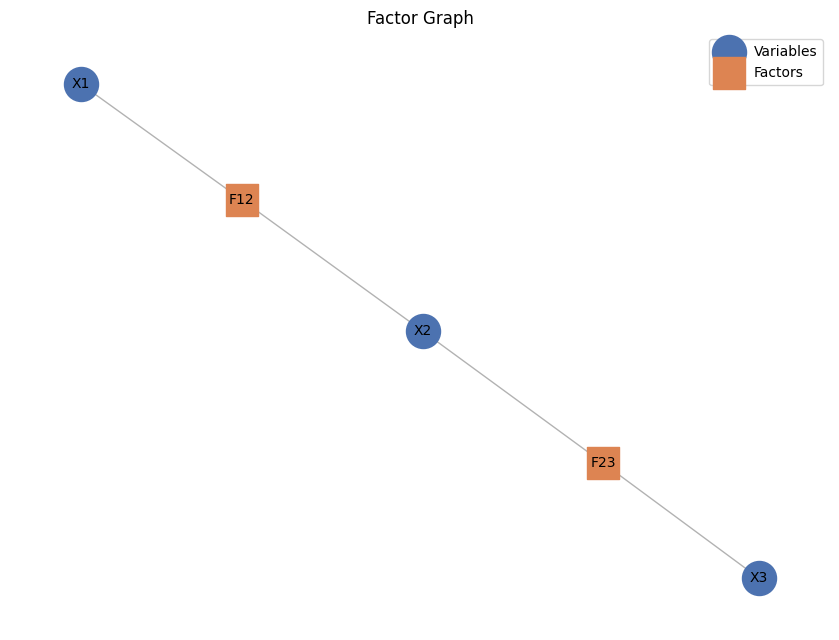

In [5]:
# scenario 2: damping only (no splitting)
# full cost table [[8,20],[32,16]]

C12_full: CostTable = np.array([[8, 20],
                                 [32, 16]])

# create variable nodes
X1_s2 = VariableAgent("X1", domain=2)
X2_s2 = VariableAgent("X2", domain=2)
X3_s2 = VariableAgent("X3", domain=2)

# create factor for X1-X2 (NOT split)
F12_s2 = FactorAgent.create_from_cost_table("F12", cost_table=C12_full)

# create unary factor for X2-X3
F23_s2 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

# build factor graph (no splitting)
fg_nosplit = FGBuilder.build_from_edges(
    variables=[X1_s2, X2_s2, X3_s2],
    factors=[F12_s2, F23_s2],
    edges={F12_s2: [X1_s2, X2_s2], F23_s2: [X2_s2, X3_s2]},
)

print("Scenario 2: Damping Only (No Splitting)")
print("Single factor F12 with cost table:")
print(C12_full)
fg_nosplit.visualize(pretty=True)

Scenario 2: Ran 15 iterations with damping_factor=0.5


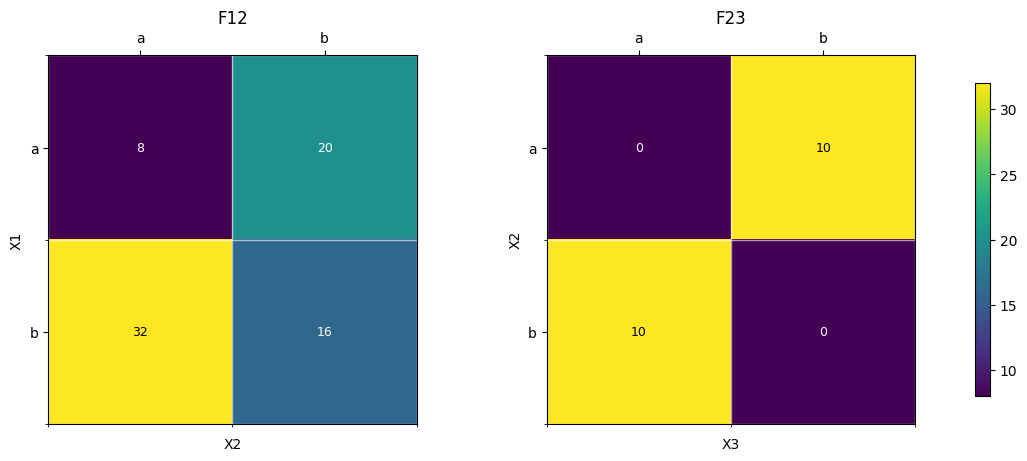

In [6]:
engine_nosplit = RDampingEngine(factor_graph=fg_nosplit, use_bct_history=True, damping_factor=damping_factor)
for i in range(num_iterations):
    engine_nosplit.step(i)

print(f"Scenario 2: Ran {num_iterations} iterations with damping_factor={damping_factor}")

viz_nosplit = SnapshotVisualizer(engine_nosplit.snapshots)
viz_nosplit.plot_cost_tables(show=False)

---
## Outgoing Q-Message Analysis

Here we analyze the **outgoing Q-message from X1** to a hypothetical next node (e.g., X4).

The output message $Q_{out}(x_1)$ is effectively the belief state (marginal) at X1, which is the sum of all incoming R-messages to X1.
- **Scenario 1 (Splitting)**: $Q_{out} = Belief(X1)$
- **Scenario 2 (No Splitting)**: $Q_{out} = Belief(X1)$

We plot the **belief difference** (belief[1] - belief[0]) over iterations.

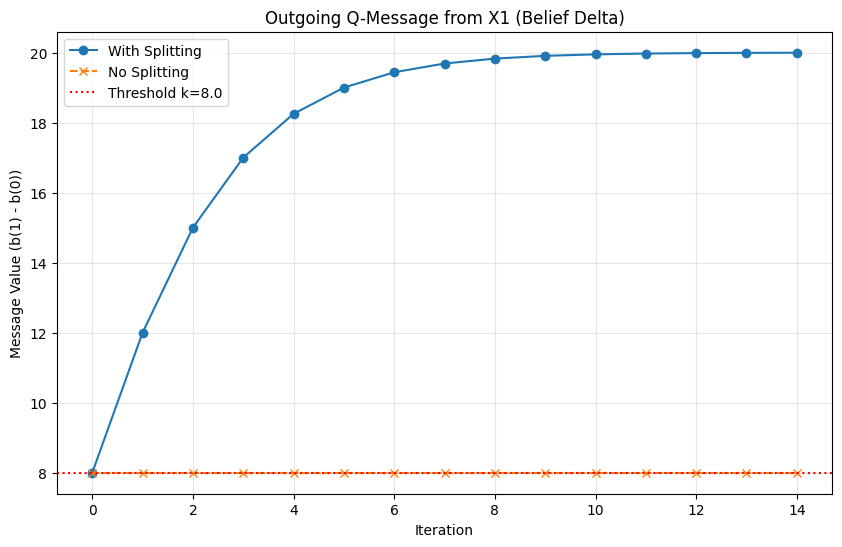

In [7]:
def extract_belief_diffs(engine) -> list[float]:
    """Extract Belief difference (belief[1] - belief[0]) at X1 for each iteration."""
    diffs = []
    
    for snap in engine.snapshots:
        # Beliefs are stored in snap.beliefs as Dict[str, np.ndarray]
        # We specifically look for 'X1'
        if 'X1' in snap.beliefs:
            b = snap.beliefs['X1']
            # Compute diff: belief(1) - belief(0)
            # This represents the net preference strength at X1
            val = b[1] - b[0]
            diffs.append(val)
        else:
            # Fallback if belief not computed yet (e.g. init step, though typically available)
            diffs.append(0.0)
            
    return diffs

q_diffs_split = extract_belief_diffs(engine_split)
q_diffs_nosplit = extract_belief_diffs(engine_nosplit)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(num_iterations), q_diffs_split, 'o-', label="With Splitting")
plt.plot(range(num_iterations), q_diffs_nosplit, 'x--', label="No Splitting")
plt.axhline(y=k, color='r', linestyle=':', label=f"Threshold k={k}")

plt.title("Outgoing Q-Message from X1 (Belief Delta)")
plt.xlabel("Iteration")
plt.ylabel("Message Value (b(1) - b(0))")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"For m0=0, k=8, lambda=0.5, predicted t_min = {t_min}")
print("\nObservations from plot:")
print("1. The 'No Splitting' scenario typically rises faster initially.")
print("2. The 'With Splitting' scenario has a delayed start due to smaller initial factor components.")
print("3. Both eventually converge to the same steady state output.")


SUMMARY
For m0=0, k=8, lambda=0.5, predicted t_min = 3

Observations from plot:
1. The 'No Splitting' scenario typically rises faster initially.
2. The 'With Splitting' scenario has a delayed start due to smaller initial factor components.
3. Both eventually converge to the same steady state output.
